<a href="https://colab.research.google.com/github/thisishasan/speech_processing/blob/main/05_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers peft accelerate sacrebleu rouge-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 kB 15.1 MB/s eta 0:00:00


In [2]:
!pip uninstall -y torchao
!pip install -q --no-cache-dir --force-reinstall "torchao>=0.16.0"

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 7.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import torch

BASE_MODEL = "llava-hf/llava-1.5-7b-hf"

ADAPTER_PATH = (
    "/content/drive/MyDrive/01_speech_processing/"
    "sp_exam_project/dataset/hf_llava_checkpoints/final_adapter"
)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [3]:
from transformers import AutoProcessor, LlavaForConditionalGeneration
from peft import PeftModel

processor = AutoProcessor.from_pretrained(BASE_MODEL)
processor.tokenizer.padding_side = "left"

base_model = LlavaForConditionalGeneration.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",
)

model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_PATH,
    local_files_only=True
)

model.eval()
print("Trained adapter loaded successfully.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Trained adapter loaded successfully.


Saving istockphoto-1444961066-612x612.jpg to istockphoto-1444961066-612x612.jpg


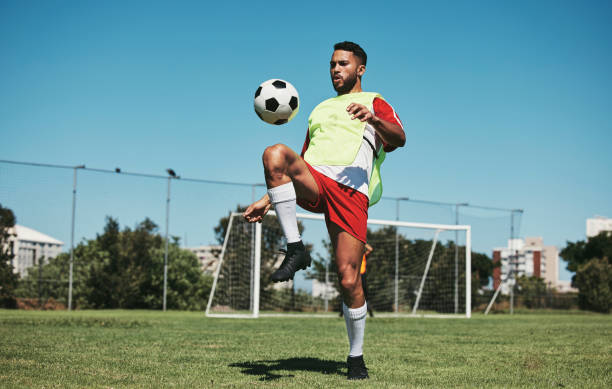

In [27]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

image_path = next(iter(uploaded))
image = Image.open(image_path).convert("RGB")

display(image)

In [51]:
question = input("Enter your question: ")

prompt = f"USER: <image>\n{question} ASSISTANT:"

inputs = processor(
    images=image,
    text=prompt,
    return_tensors="pt",
)

inputs = {
    key: value.to(device) if torch.is_tensor(value) else value
    for key, value in inputs.items()
}

with torch.inference_mode():
    output = model.generate(
        **inputs,
        max_new_tokens=612,
        do_sample=True,
        use_cache=False,
    )

prompt_length = inputs["input_ids"].shape[1]
answer_tokens = output[:, prompt_length:]

predicted_answer = processor.batch_decode(
    answer_tokens,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0].strip()

print("Question:", question)
print("Predicted answer:", predicted_answer)

Enter your question: Please describe this image in one sentence
Question: Please describe this image in one sentence
Predicted answer: A man wearing a green vest and red shorts kicks a soccer ball backward.
